### MNISTデータセット

size: 60000
type: <class 'PIL.Image.Image'>
label: 5


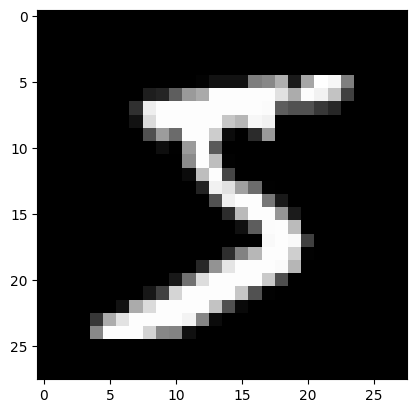

In [1]:
import torchvision
import matplotlib.pyplot as plt

# MNISTデータセットを読み込む
dataset = torchvision.datasets.MNIST(
    root = './data',
    train = True, 
    transform = None,
    download=True,
)

# dataセットから0番目の画像を選択
x, label = dataset[0]

print('size:', len(dataset))
print('type:', type(x))
print('label:', label)

plt.imshow(x, cmap='gray')
plt.show()

### 前処理

In [2]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.ToTensor()  # PIL画像をTensorに変換するため

dataset = torchvision.datasets.MNIST(
    root = './data',
    train = True, 
    transform=transform, #前処理の指定
    download = True,
)

x, label = dataset[0]
print('type:', type(x))
print('shape:', x.shape)

type: <class 'torch.Tensor'>
shape: torch.Size([1, 28, 28])


### データローダー

MNISTは全部で60000個のデータがある．NNの学習では，それらをまとめて処理せず，通常は，データセットを分割して使う．データセット全体から取り出す一部のデータを **ミニバッチ(Mini Batch)** と呼ぶ．

> ミニバッチで学習する時に，**「データセット全体を見る」という単位をエポック(Epoch)と呼ぶ**．例えば，バッチサイズが100の場合には，60000個のMNISTデータは，600回のミニバッチ処理で1エポックになる．

In [3]:
# torch.utils.data.DataLoaderを使ってミニバッチを取得
import torch

dataloader = torch.utils.data.DataLoader(
    dataset, 
    batch_size=32,  # 60000 / 32 = 1875 epochs
    shuffle=True
)

for batch_idx, (x, label) in enumerate(dataloader):
    print(f'batch_idx={batch_idx}')
    print('x_shape:', x.shape)
    print('label_shape:', label.shape)
    break  # 1バッチだけ表示するためにbreakで抜ける

batch_idx=0
x_shape: torch.Size([32, 1, 28, 28])
label_shape: torch.Size([32])


---
### 実際に学習

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# --- データセットとデータローダー ---
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

batch_size = 100
hidden_size = 100
output_size = 10

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- モデル定義 ---
class MNISTModel(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=hidden_size, output_size=output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # (batch, 1, 28, 28) -> (batch, 784)
        y = self.linear1(x)
        y = F.sigmoid(y)
        y = self.linear2(y)
        return y

# --- 学習関数 ---
def train_mnist(optimizer_class, lr, epochs, seed=42, **opt_kwargs):
    torch.manual_seed(seed)
    model = MNISTModel()
    optimizer = optimizer_class(model.parameters(), lr=lr, **opt_kwargs)

    train_losses, train_accuracies = [], []
    test_losses, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        train_correct = 0
        train_total = 0

        for x, label in train_loader:
            y_pred = model(x)
            loss = F.cross_entropy(y_pred, label)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            epoch_loss += loss.item()
            _, predicted = torch.max(y_pred, 1)
            train_total += label.size(0)
            train_correct += (predicted == label).sum().item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # テストデータで評価
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, label in test_loader:
                y_pred = model(x)
                test_loss += F.cross_entropy(y_pred, label).item()
                _, predicted = torch.max(y_pred, 1)
                total += label.size(0)
                correct += (predicted == label).sum().item()

        avg_test_loss = test_loss / len(test_loader)
        test_acc = correct / total
        test_losses.append(avg_test_loss)
        test_accuracies.append(test_acc)
        print(f'  epoch {epoch+1}/{epochs}  train_loss: {avg_train_loss:.4f}  train_acc: {train_acc:.4f}  test_loss: {avg_test_loss:.4f}  test_acc: {test_acc:.4f}')

    return model, train_losses, train_accuracies, test_losses, test_accuracies

# --- 可視化関数 ---
def display_mnist_results(model, train_losses, train_accuracies, test_losses, test_accuracies,
                          optimizer_name, lr, epochs, ax_loss=None, ax_acc=None, show_predictions=True):
    """学習曲線の描画 (ax_loss, ax_accが与えられた場合はそこに描画)"""
    standalone = ax_loss is None
    if standalone:
        fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    ep_range = range(1, epochs+1)
    ax_loss.plot(ep_range, train_losses, label='train')
    ax_loss.plot(ep_range, test_losses,  label='test')
    ax_loss.set_xlabel('epoch')
    ax_loss.set_ylabel('loss')
    ax_loss.set_title(f'{optimizer_name} (lr={lr})\nLoss')
    ax_loss.legend()
    ax_loss.grid()

    ax_acc.plot(ep_range, train_accuracies, label='train')
    ax_acc.plot(ep_range, test_accuracies,  label='test')
    ax_acc.set_xlabel('epoch')
    ax_acc.set_ylabel('accuracy')
    ax_acc.set_title(f'{optimizer_name} (lr={lr})\nAccuracy (test={test_accuracies[-1]:.4f})')
    ax_acc.legend()
    ax_acc.grid()

    if standalone:
        plt.tight_layout()
        plt.show()

    if not show_predictions:
        return

    # 正解/不正解に分類して表示
    model.eval()
    corrects = []
    incorrects = []

    with torch.no_grad():
        for i in range(len(test_dataset)):
            x, label = test_dataset[i]
            y_pred = model(x.unsqueeze(0))
            probs = F.softmax(y_pred, dim=1).squeeze()
            pred_label = torch.argmax(probs).item()
            prob = probs[pred_label].item()
            if pred_label == label:
                corrects.append((i, label, pred_label, prob))
            else:
                incorrects.append((i, label, pred_label, prob))
            if len(corrects) >= 5 and len(incorrects) >= 5:
                break

    n_cols = 5
    fig, axes = plt.subplots(2, n_cols, figsize=(14, 7), gridspec_kw={'hspace': 0.5})

    for col in range(n_cols):
        ax = axes[0][col]
        if col < len(corrects):
            idx, label, pred_label, prob = corrects[col]
            x, _ = test_dataset[idx]
            ax.imshow(x.squeeze().numpy(), cmap='gray')
            ax.set_title(f'pred: {pred_label} ({prob:.2%})\ntrue: {label}', fontsize=10, color='green')
        ax.axis('off')

    for col in range(n_cols):
        ax = axes[1][col]
        if col < len(incorrects):
            idx, label, pred_label, prob = incorrects[col]
            x, _ = test_dataset[idx]
            ax.imshow(x.squeeze().numpy(), cmap='gray')
            ax.set_title(f'pred: {pred_label} ({prob:.2%})\ntrue: {label}', fontsize=10, color='red')
        ax.axis('off')

    axes[0][0].set_ylabel('Correct', fontsize=14, rotation=0, labelpad=60, va='center')
    axes[1][0].set_ylabel('Incorrect', fontsize=14, rotation=0, labelpad=60, va='center')
    fig.suptitle(f'{optimizer_name} (lr={lr}) - Prediction Examples (softmax probability)', fontsize=14)
    plt.show()

### SGD / Momentum / Adagrad / Adam / AdamW /

SGD (lr=0.1)
  epoch 1/30  train_loss: 1.1516  train_acc: 0.7169  test_loss: 0.5305  test_acc: 0.8724
  epoch 2/30  train_loss: 0.4484  train_acc: 0.8831  test_loss: 0.3714  test_acc: 0.8997
  epoch 3/30  train_loss: 0.3595  train_acc: 0.8996  test_loss: 0.3221  test_acc: 0.9103
  epoch 4/30  train_loss: 0.3225  train_acc: 0.9078  test_loss: 0.2998  test_acc: 0.9140
  epoch 5/30  train_loss: 0.2995  train_acc: 0.9143  test_loss: 0.2791  test_acc: 0.9201
  epoch 6/30  train_loss: 0.2825  train_acc: 0.9188  test_loss: 0.2657  test_acc: 0.9238
  epoch 7/30  train_loss: 0.2684  train_acc: 0.9229  test_loss: 0.2552  test_acc: 0.9269
  epoch 8/30  train_loss: 0.2562  train_acc: 0.9267  test_loss: 0.2449  test_acc: 0.9300
  epoch 9/30  train_loss: 0.2451  train_acc: 0.9295  test_loss: 0.2350  test_acc: 0.9332
  epoch 10/30  train_loss: 0.2349  train_acc: 0.9324  test_loss: 0.2270  test_acc: 0.9356
  epoch 11/30  train_loss: 0.2255  train_acc: 0.9353  test_loss: 0.2173  test_acc: 0.9396
  epoc

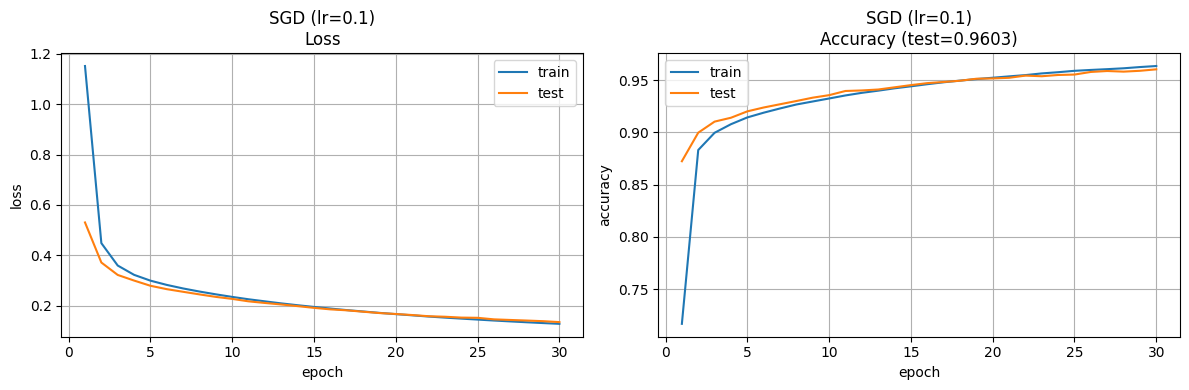

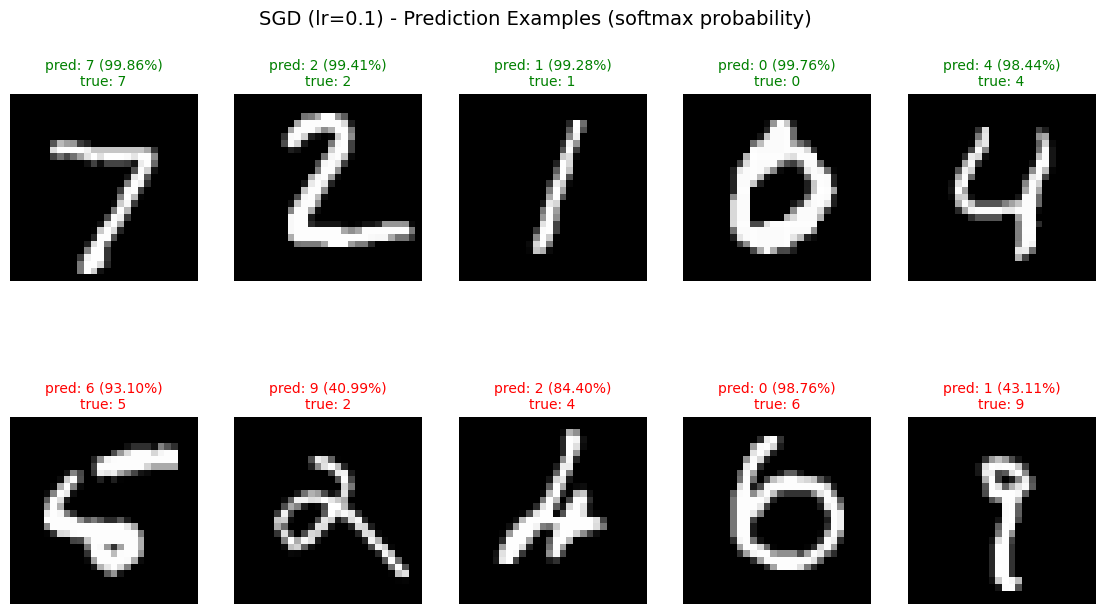

  -> saved to SGD_lr0.1.csv
Momentum (lr=0.1, momentum=0.9)
  epoch 1/30  train_loss: 0.4463  train_acc: 0.8669  test_loss: 0.2416  test_acc: 0.9293
  epoch 2/30  train_loss: 0.2117  train_acc: 0.9385  test_loss: 0.1714  test_acc: 0.9497
  epoch 3/30  train_loss: 0.1579  train_acc: 0.9539  test_loss: 0.1385  test_acc: 0.9573
  epoch 4/30  train_loss: 0.1257  train_acc: 0.9635  test_loss: 0.1200  test_acc: 0.9635
  epoch 5/30  train_loss: 0.1057  train_acc: 0.9687  test_loss: 0.1045  test_acc: 0.9675
  epoch 6/30  train_loss: 0.0896  train_acc: 0.9737  test_loss: 0.0970  test_acc: 0.9710
  epoch 7/30  train_loss: 0.0781  train_acc: 0.9778  test_loss: 0.0907  test_acc: 0.9712
  epoch 8/30  train_loss: 0.0691  train_acc: 0.9797  test_loss: 0.0838  test_acc: 0.9736
  epoch 9/30  train_loss: 0.0614  train_acc: 0.9827  test_loss: 0.0827  test_acc: 0.9730
  epoch 10/30  train_loss: 0.0550  train_acc: 0.9848  test_loss: 0.0772  test_acc: 0.9754
  epoch 11/30  train_loss: 0.0496  train_acc: 0.9

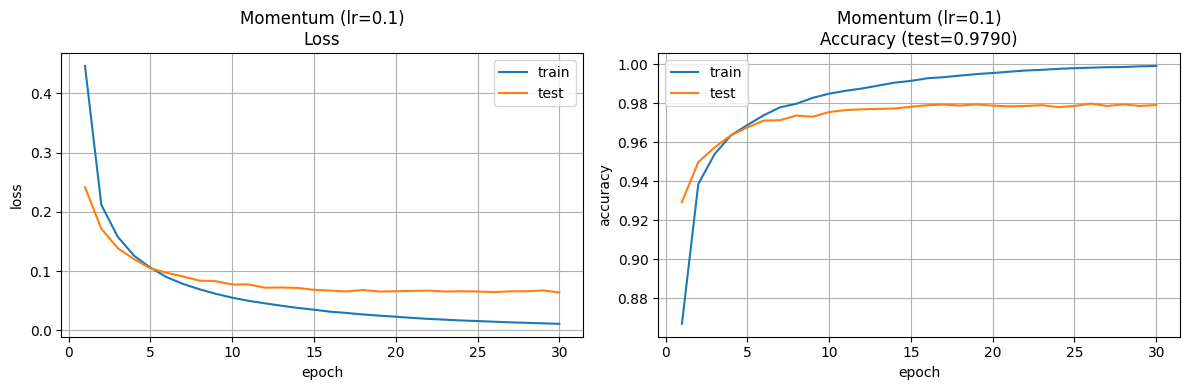

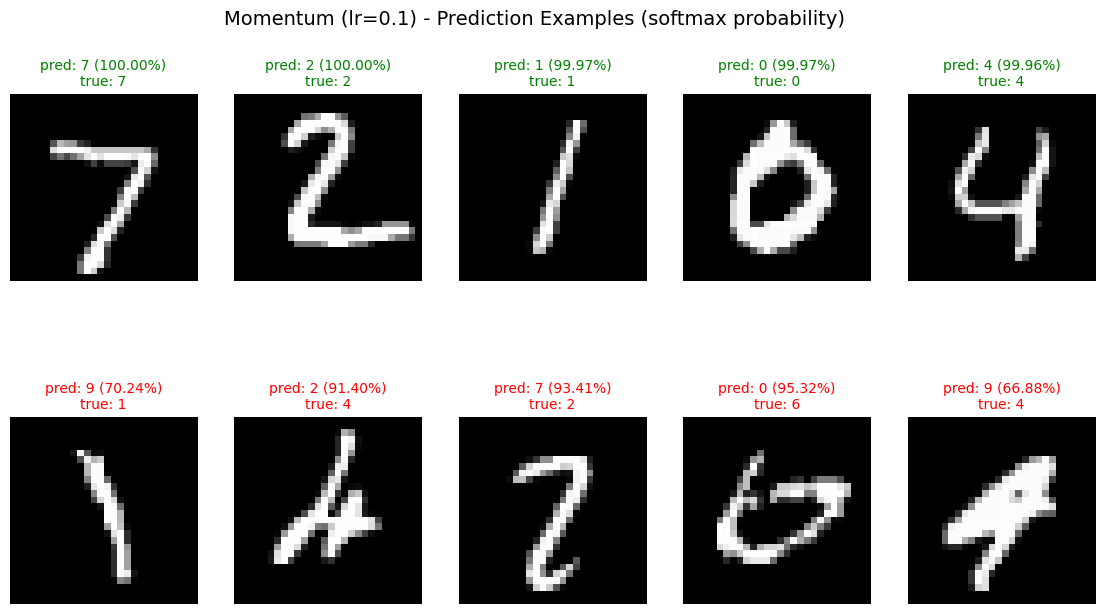

  -> saved to Momentum_lr0.1_momentum0.9.csv
AdaGrad (lr=0.01)
  epoch 1/30  train_loss: 0.5322  train_acc: 0.8762  test_loss: 0.3311  test_acc: 0.9133
  epoch 2/30  train_loss: 0.3109  train_acc: 0.9149  test_loss: 0.2811  test_acc: 0.9209
  epoch 3/30  train_loss: 0.2741  train_acc: 0.9227  test_loss: 0.2565  test_acc: 0.9276
  epoch 4/30  train_loss: 0.2534  train_acc: 0.9282  test_loss: 0.2415  test_acc: 0.9303
  epoch 5/30  train_loss: 0.2387  train_acc: 0.9321  test_loss: 0.2301  test_acc: 0.9336
  epoch 6/30  train_loss: 0.2277  train_acc: 0.9357  test_loss: 0.2213  test_acc: 0.9360
  epoch 7/30  train_loss: 0.2186  train_acc: 0.9379  test_loss: 0.2144  test_acc: 0.9383
  epoch 8/30  train_loss: 0.2110  train_acc: 0.9401  test_loss: 0.2080  test_acc: 0.9396
  epoch 9/30  train_loss: 0.2044  train_acc: 0.9421  test_loss: 0.2030  test_acc: 0.9415
  epoch 10/30  train_loss: 0.1986  train_acc: 0.9438  test_loss: 0.1976  test_acc: 0.9440
  epoch 11/30  train_loss: 0.1934  train_acc: 

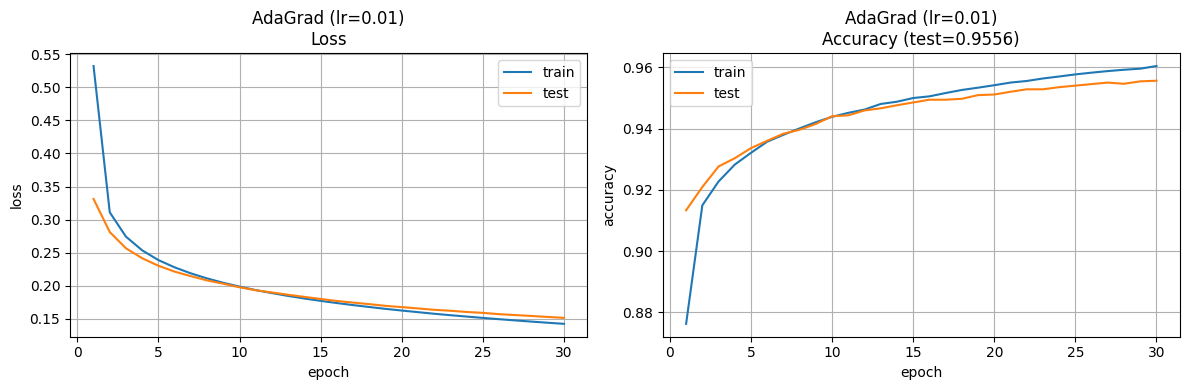

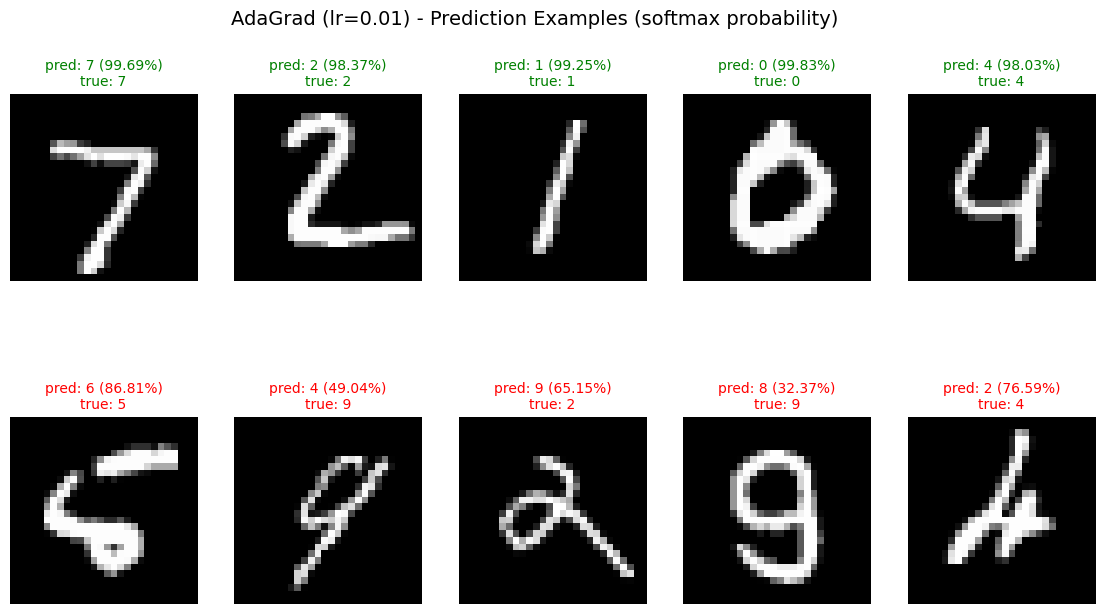

  -> saved to AdaGrad_lr0.01.csv
RMSProp (lr=0.001)
  epoch 1/30  train_loss: 0.4784  train_acc: 0.8831  test_loss: 0.2705  test_acc: 0.9246
  epoch 2/30  train_loss: 0.2433  train_acc: 0.9302  test_loss: 0.2107  test_acc: 0.9395
  epoch 3/30  train_loss: 0.1937  train_acc: 0.9437  test_loss: 0.1748  test_acc: 0.9481
  epoch 4/30  train_loss: 0.1619  train_acc: 0.9532  test_loss: 0.1586  test_acc: 0.9536
  epoch 5/30  train_loss: 0.1386  train_acc: 0.9607  test_loss: 0.1368  test_acc: 0.9596
  epoch 6/30  train_loss: 0.1209  train_acc: 0.9650  test_loss: 0.1231  test_acc: 0.9629
  epoch 7/30  train_loss: 0.1064  train_acc: 0.9702  test_loss: 0.1142  test_acc: 0.9647
  epoch 8/30  train_loss: 0.0943  train_acc: 0.9732  test_loss: 0.1046  test_acc: 0.9680
  epoch 9/30  train_loss: 0.0842  train_acc: 0.9764  test_loss: 0.1009  test_acc: 0.9698
  epoch 10/30  train_loss: 0.0757  train_acc: 0.9790  test_loss: 0.0963  test_acc: 0.9702
  epoch 11/30  train_loss: 0.0684  train_acc: 0.9812  tes

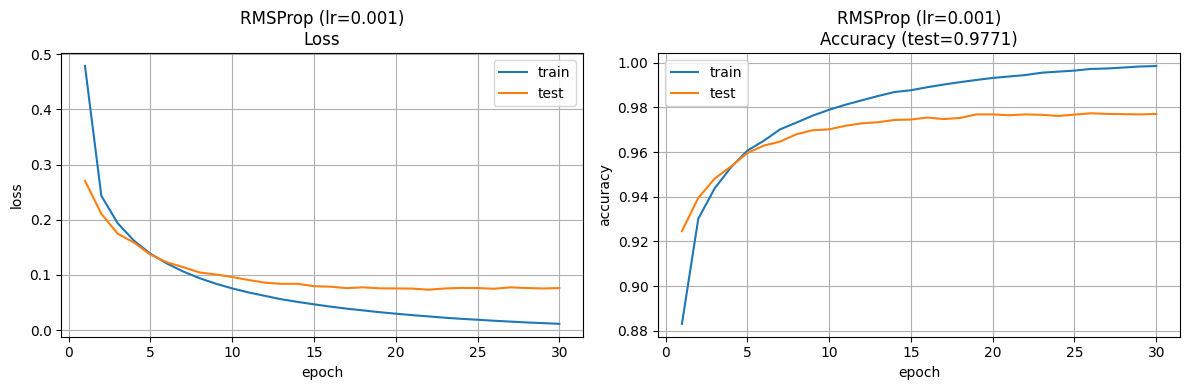

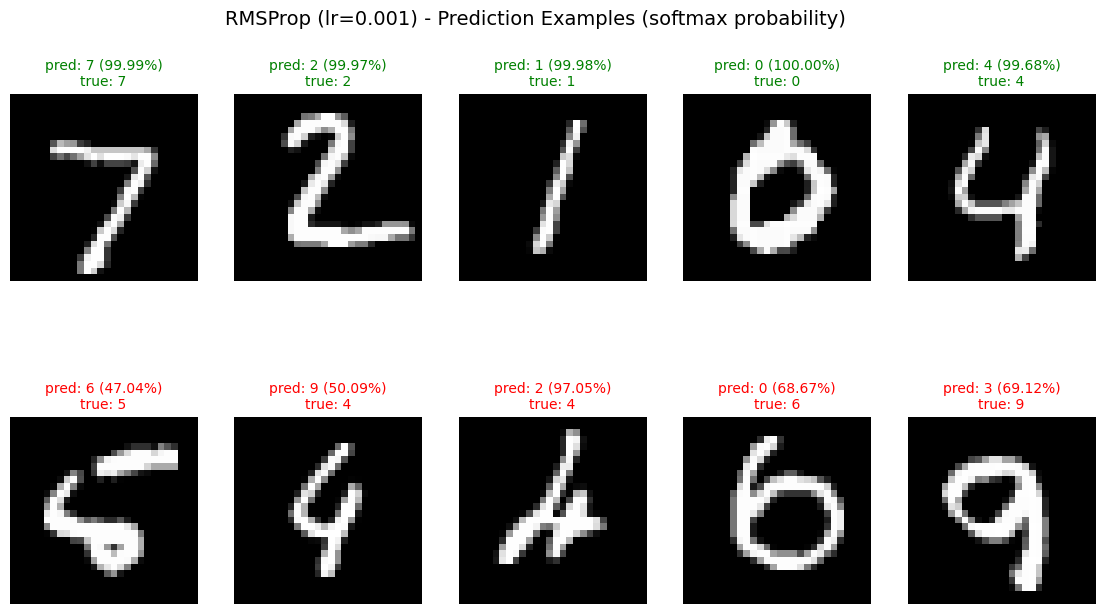

  -> saved to RMSProp_lr0.001.csv
AdaDelta (lr=1.0)
  epoch 1/30  train_loss: 0.5534  train_acc: 0.8574  test_loss: 0.2791  test_acc: 0.9198
  epoch 2/30  train_loss: 0.2542  train_acc: 0.9263  test_loss: 0.2167  test_acc: 0.9399
  epoch 3/30  train_loss: 0.2013  train_acc: 0.9417  test_loss: 0.1757  test_acc: 0.9498
  epoch 4/30  train_loss: 0.1668  train_acc: 0.9516  test_loss: 0.1661  test_acc: 0.9519
  epoch 5/30  train_loss: 0.1421  train_acc: 0.9587  test_loss: 0.1355  test_acc: 0.9607
  epoch 6/30  train_loss: 0.1234  train_acc: 0.9634  test_loss: 0.1222  test_acc: 0.9638
  epoch 7/30  train_loss: 0.1091  train_acc: 0.9691  test_loss: 0.1128  test_acc: 0.9668
  epoch 8/30  train_loss: 0.0973  train_acc: 0.9722  test_loss: 0.1040  test_acc: 0.9689
  epoch 9/30  train_loss: 0.0878  train_acc: 0.9750  test_loss: 0.1006  test_acc: 0.9696
  epoch 10/30  train_loss: 0.0797  train_acc: 0.9774  test_loss: 0.0973  test_acc: 0.9703
  epoch 11/30  train_loss: 0.0730  train_acc: 0.9795  tes

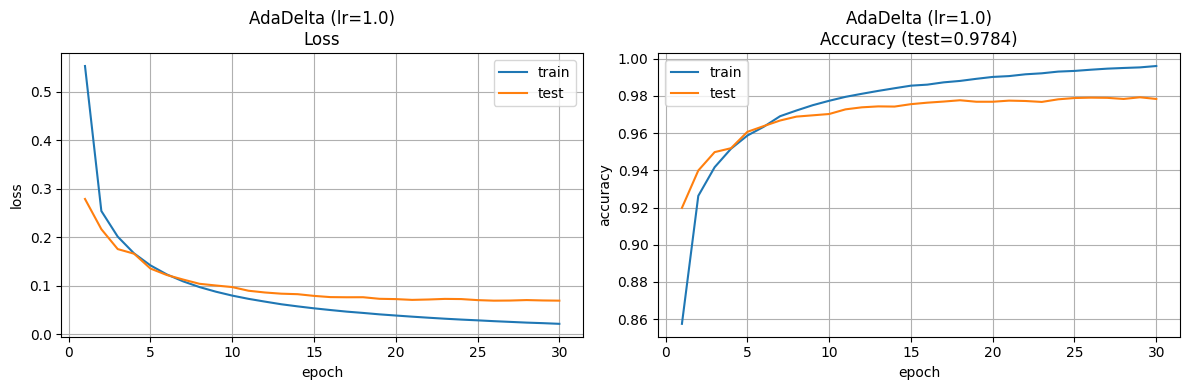

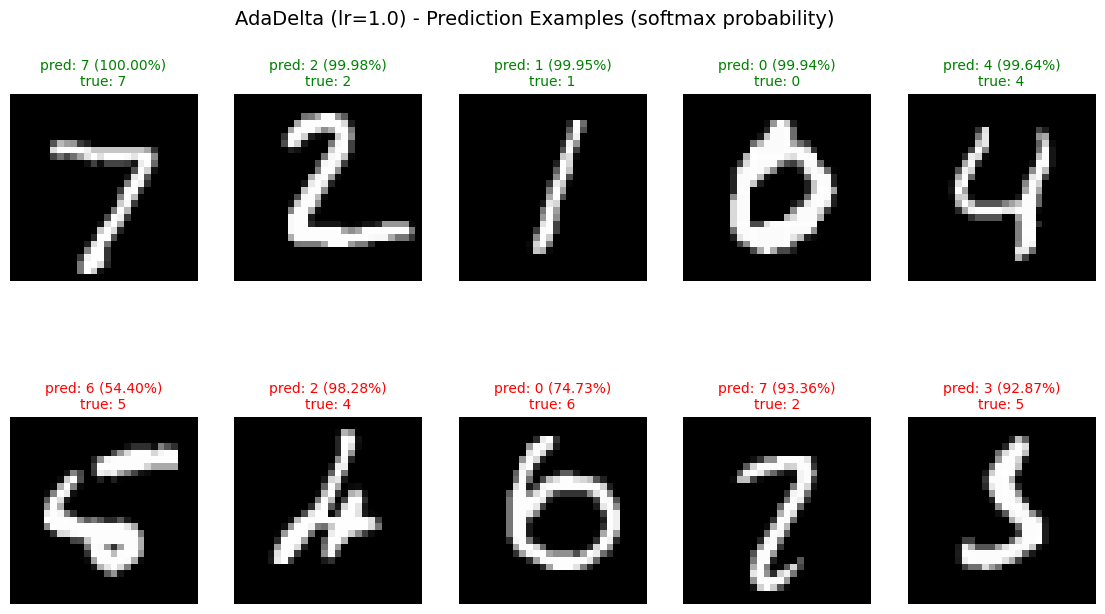

  -> saved to AdaDelta_lr1.0.csv
Adam (lr=0.001)
  epoch 1/30  train_loss: 0.6603  train_acc: 0.8501  test_loss: 0.2997  test_acc: 0.9190
  epoch 2/30  train_loss: 0.2665  train_acc: 0.9247  test_loss: 0.2309  test_acc: 0.9314
  epoch 3/30  train_loss: 0.2113  train_acc: 0.9394  test_loss: 0.1905  test_acc: 0.9449
  epoch 4/30  train_loss: 0.1772  train_acc: 0.9495  test_loss: 0.1660  test_acc: 0.9526
  epoch 5/30  train_loss: 0.1531  train_acc: 0.9563  test_loss: 0.1477  test_acc: 0.9566
  epoch 6/30  train_loss: 0.1341  train_acc: 0.9615  test_loss: 0.1335  test_acc: 0.9610
  epoch 7/30  train_loss: 0.1184  train_acc: 0.9660  test_loss: 0.1255  test_acc: 0.9629
  epoch 8/30  train_loss: 0.1054  train_acc: 0.9704  test_loss: 0.1146  test_acc: 0.9661
  epoch 9/30  train_loss: 0.0942  train_acc: 0.9735  test_loss: 0.1101  test_acc: 0.9666
  epoch 10/30  train_loss: 0.0848  train_acc: 0.9768  test_loss: 0.1020  test_acc: 0.9681
  epoch 11/30  train_loss: 0.0762  train_acc: 0.9794  test_l

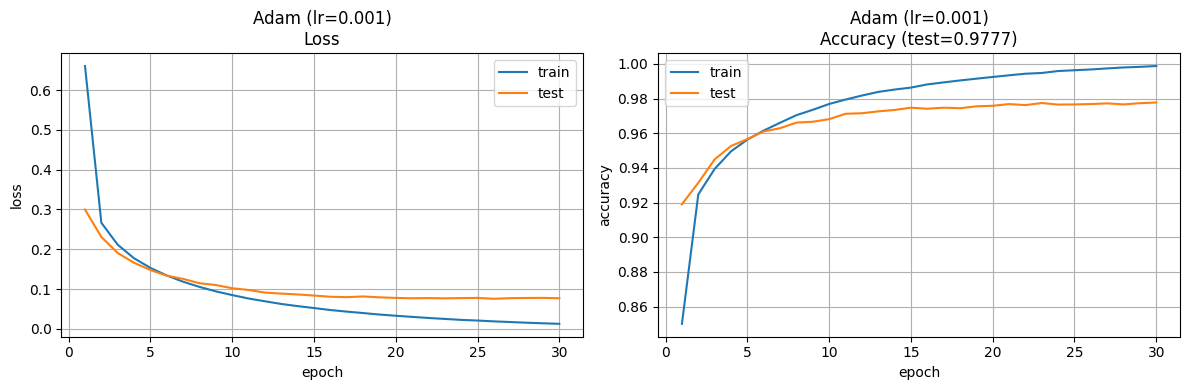

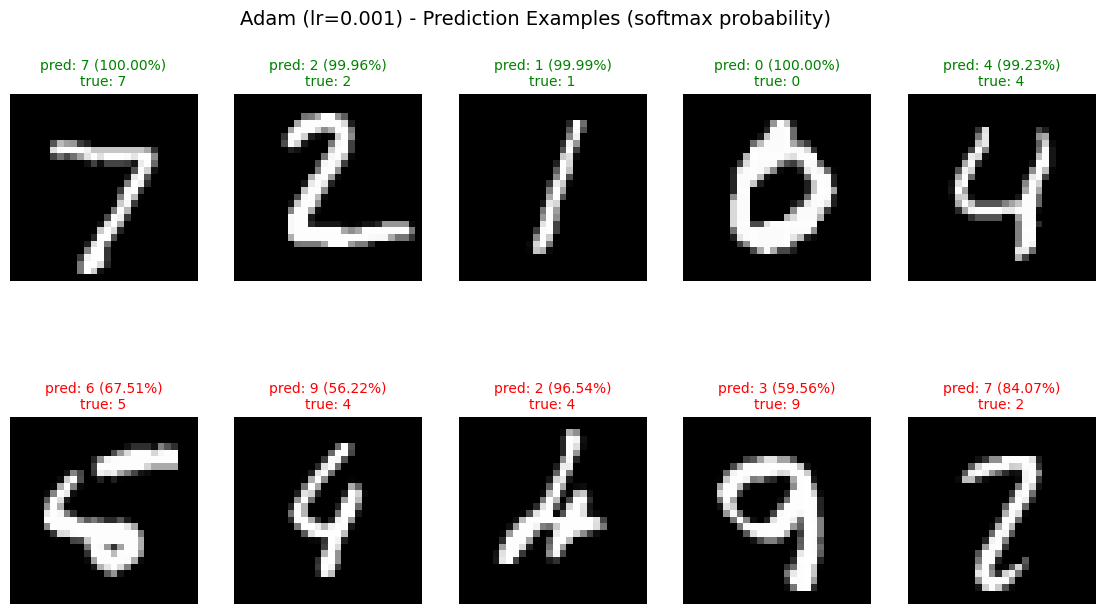

  -> saved to Adam_lr0.001.csv
AdamW (lr=0.001, weight_decay=0.01)
  epoch 1/30  train_loss: 0.6609  train_acc: 0.8500  test_loss: 0.3003  test_acc: 0.9190
  epoch 2/30  train_loss: 0.2673  train_acc: 0.9247  test_loss: 0.2317  test_acc: 0.9311
  epoch 3/30  train_loss: 0.2123  train_acc: 0.9393  test_loss: 0.1915  test_acc: 0.9447
  epoch 4/30  train_loss: 0.1784  train_acc: 0.9492  test_loss: 0.1670  test_acc: 0.9524
  epoch 5/30  train_loss: 0.1545  train_acc: 0.9561  test_loss: 0.1488  test_acc: 0.9567
  epoch 6/30  train_loss: 0.1356  train_acc: 0.9612  test_loss: 0.1347  test_acc: 0.9608
  epoch 7/30  train_loss: 0.1200  train_acc: 0.9657  test_loss: 0.1267  test_acc: 0.9626
  epoch 8/30  train_loss: 0.1071  train_acc: 0.9701  test_loss: 0.1157  test_acc: 0.9658
  epoch 9/30  train_loss: 0.0960  train_acc: 0.9732  test_loss: 0.1111  test_acc: 0.9663
  epoch 10/30  train_loss: 0.0868  train_acc: 0.9765  test_loss: 0.1030  test_acc: 0.9677
  epoch 11/30  train_loss: 0.0783  train_a

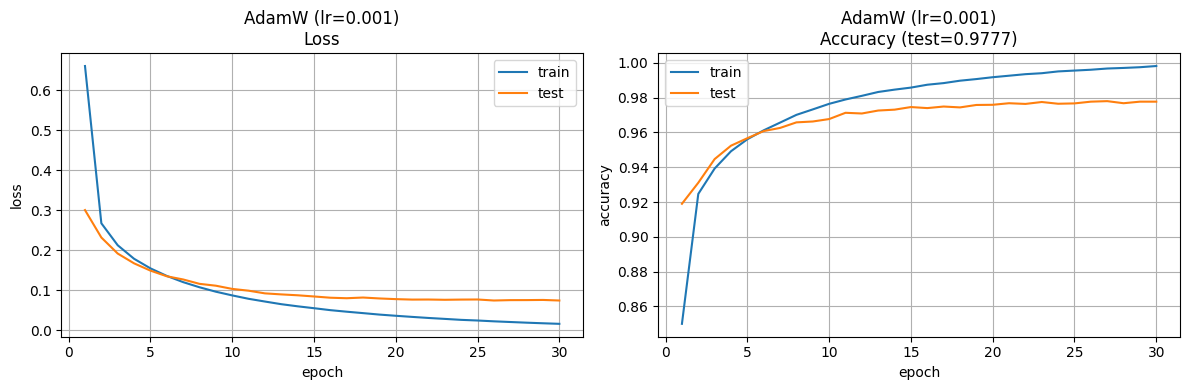

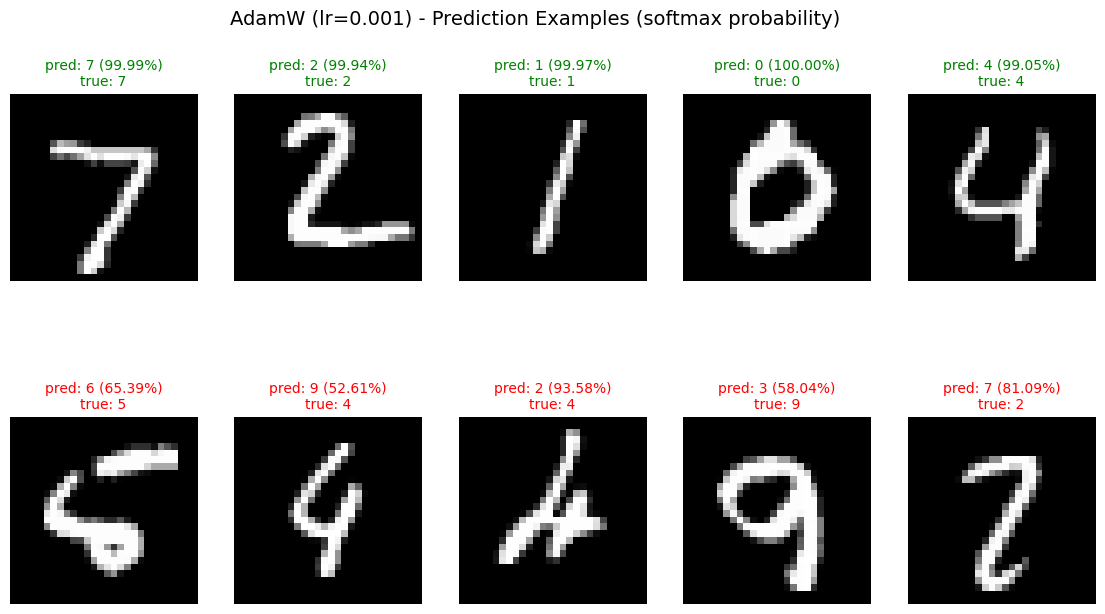

  -> saved to AdamW_lr0.001_weight_decay0.01.csv


In [ ]:
import os
import csv

results_dir = 'results'
os.makedirs(results_dir, exist_ok=True)

def make_csv_filename(name, lr, kwargs):
    parts = [name, f'lr{lr}']
    for k, v in kwargs.items():
        parts.append(f'{k}{v}')
    return os.path.join(results_dir, '_'.join(parts) + '.csv')

optimizers = [
    ('SGD',      torch.optim.SGD,      0.1,   {}),
    ('Momentum', torch.optim.SGD,      0.1,   {'momentum': 0.9}),
    ('AdaGrad',  torch.optim.Adagrad,  0.01,  {}),
    ('RMSProp',  torch.optim.RMSprop,  0.001, {}),
    ('AdaDelta', torch.optim.Adadelta, 1.0,   {}),
    ('Adam',     torch.optim.Adam,     0.001, {}),
    ('AdamW',    torch.optim.AdamW,    0.001, {'weight_decay': 0.01}),
]

epochs = 30
hidden_size = 100
seed = 42

results = {}
fieldnames = ['optimizer', 'lr', 'kwargs', 'total_epochs', 'batch_size', 'hidden_size', 'seed',
              'epoch', 'train_loss', 'train_acc', 'test_loss', 'test_acc']

for name, opt_class, lr, kwargs in optimizers:
    extra = ', '.join(f'{k}={v}' for k, v in kwargs.items())
    label = f'{name} (lr={lr}' + (f', {extra})' if extra else ')')
    print(label)
    model, train_losses, train_accs, test_losses, test_accs = train_mnist(opt_class, lr=lr, epochs=epochs, seed=seed, **kwargs)
    results[name] = (model, train_losses, train_accs, test_losses, test_accs, lr)
    display_mnist_results(model, train_losses, train_accs, test_losses, test_accs,
                          name, lr=lr, epochs=epochs)

    csv_path = make_csv_filename(name, lr, kwargs)
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for ep in range(epochs):
            writer.writerow({
                'optimizer':    name,
                'lr':           lr,
                'kwargs':       str(kwargs),
                'total_epochs': epochs,
                'batch_size':   batch_size,
                'hidden_size':  hidden_size,
                'seed':         seed,
                'epoch':        ep + 1,
                'train_loss':   train_losses[ep],
                'train_acc':    train_accs[ep],
                'test_loss':    test_losses[ep],
                'test_acc':     test_accs[ep],
            })
    print(f'  -> saved to {csv_path}')

### オプティマイザ比較

In [56]:
import os
import csv
import glob
import matplotlib.pyplot as plt

font_size_title = 14
font_size_label = 10

# results/ 以下の全CSVを読み込み
csv_files = sorted(glob.glob(os.path.join('results', '*.csv')))
data = {}

for path in csv_files:
    with open(path, newline='') as f:
        rows = list(csv.DictReader(f))
    if not rows:
        continue
    name = rows[0]['optimizer']
    data[name] = {
        'lr':         float(rows[0]['lr']),
        'kwargs':     rows[0]['kwargs'],
        'epochs':     [int(r['epoch'])       for r in rows],
        'train_loss': [float(r['train_loss']) for r in rows],
        'train_acc':  [float(r['train_acc'])  for r in rows],
        'test_loss':  [float(r['test_loss'])  for r in rows],
        'test_acc':   [float(r['test_acc'])   for r in rows],
    }

def plot_comparison(selected=[]):
    d = {k: v for k, v in data.items() if k in selected} if selected else data

    fig, axes = plt.subplots(1, 3, figsize=(15, 8))
    ax1, ax2, ax3 = axes

    total_epochs = max(max(v['epochs']) for v in d.values())

    for name, v in d.items():
        lr     = v['lr']
        kwargs = v['kwargs']
        extra  = '' if kwargs == '{}' else f', {kwargs[1:-1]}'
        label  = f'{name} (lr={lr}{extra})'
        ax1.plot(v['epochs'], v['train_loss'], label=label, linewidth=2)
        ax2.plot(v['epochs'], v['test_loss'],  label=label, linewidth=2)
        ax3.plot(v['epochs'], v['test_acc'],   label=label, linewidth=2)

    ax1.set_xlabel('epoch'); ax1.set_ylabel('loss');     ax1.set_title('Train Loss');     ax1.legend(fontsize=font_size_label); ax1.grid()
    ax2.set_xlabel('epoch'); ax2.set_ylabel('loss');     ax2.set_title('Test Loss');      ax2.legend(fontsize=font_size_label); ax2.grid()
    ax3.set_xlabel('epoch'); ax3.set_ylabel('accuracy'); ax3.set_title('Test Accuracy');  ax3.legend(fontsize=font_size_label); ax3.grid()

    fig.suptitle(f'Optimizer Comparison (MNIST)\nbatchsize={batch_size}, hidden_size={hidden_size}, epochs={total_epochs}', fontsize=font_size_title)
    plt.tight_layout()
    plt.show()

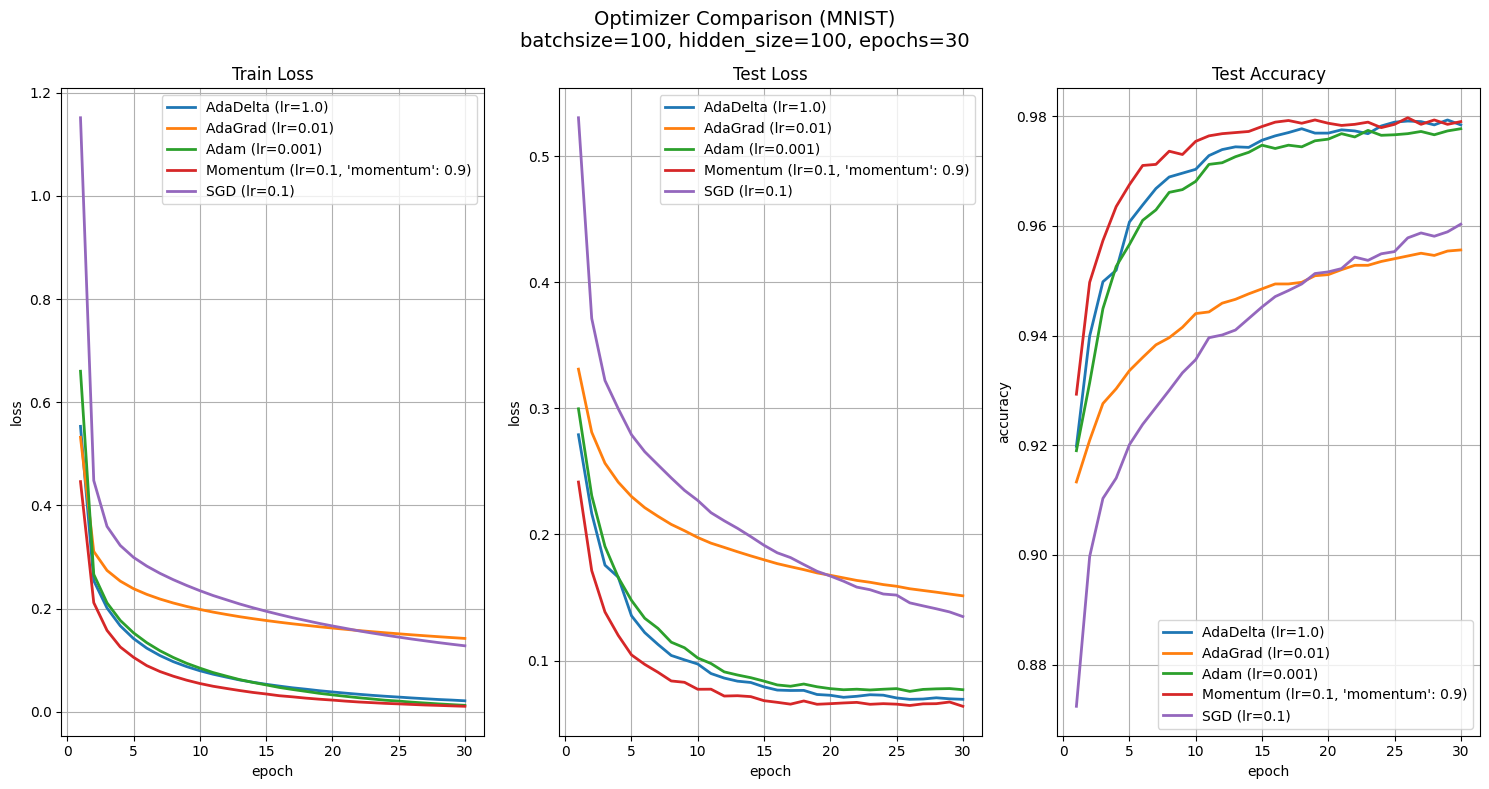

In [57]:
plot_comparison(['SGD', 'Momentum', 'AdaGrad', 'AdaDelta', 'Adam'])
# plot_comparison(['Momentum', 'AdaDelta','RMSProp', 'AdamW'])
# plot_comparison(['Adam', 'AdamW'])
# plot_comparison()  # 全件


<!-- | **SGD**      | 1951頃〜 | Robbins–Monro の stochastic approximation が源流。SGD的な考え方の原型([Robbins and Monro, 1951, *The Annals of Mathematical Statistics*][1]) | -->

| Optimizer    | 年 | 内容 |
| ------------ | --: | ---- |
| **Momentum** | 1964 | 過去の更新方向を慣性として使用([Polyak, 1964, *USSR Computational Mathematics and Mathematical Physics*][2]) |
| **AdaGrad**  | 2011 | 勾配二乗の累積和を用いて，パラメータごとに学習率を調整 adaptive method([Duchi et al., 2011, *Journal of Machine Learning Research*][3]) |
| **RMSProp**  | 2012 | 勾配二乗の指数移動平均を用いて，パラメータごとの学習率を調整
| **AdaDelta** | 2012 | AdaGrad の学習率が小さくなり続ける問題を緩和. 更に，学習率そのものを勾配二乗平均と更新量二乗平均で自動更新([Zeiler et al., 2012, *arXiv*][4]) |
| **Adam**     | 2014 / 2015 | Momentum 的な一次モーメント + AdaGrad/RMSProp 的な二次モーメントを使う([Kingma and Ba, 2014, *arXiv*; 2015, *International Conference on Learning Representations*][5]) |
| **AdamW** | 2017 / 2019 | Adam における L2 正則化と weight decay の非等価性を指摘し、weight decay を勾配更新から分離([Loshchilov and Hutter, 2017, *arXiv*; 2019, *International Conference on Learning Representations*][6]) |

<!-- [1]: https://www.columbia.edu/~ww2040/8100F16/RM51.pdf "A Stochastic Approximation Method" -->
[2]: https://papers.baulab.info/papers/also/Polyak-1964.pdf "Some Methods of Speeding up the Convergence of Iteration Methods"
[3]: https://jmlr.csail.mit.edu/papers/v12/duchi11a.html "Adaptive Subgradient Methods for Online Learning and Stochastic Optimization"
[4]: https://arxiv.org/abs/1212.5701 "ADADELTA: An Adaptive Learning Rate Method"
[5]: https://arxiv.org/abs/1412.6980 "Adam: A Method for Stochastic Optimization"
[6]: https://arxiv.org/abs/1711.05101 "Decoupled Weight Decay Regularization"


<!-- | 手法       | 保持する量                                           | 何をしているか                   |
| -------- | ----------------------------------------------- | ------------------------- |
| SGD      | なし                                              | 現在の勾配方向に進む                |
| Momentum | $\boldsymbol{v}$                                | 過去の更新方向を慣性として使う           |
| Adagrad  | $\boldsymbol{h}$                                | 過去の勾配二乗和で各要素の学習率を調整       |
| AdaDelta | $\boldsymbol{h}, \boldsymbol{s}$                | 勾配二乗平均と更新量二乗平均で自動調整       |
| Adam     | $\boldsymbol{m}, \boldsymbol{v}$                | Momentum + 勾配二乗平均による適応学習率 |
| AdamW    | $\boldsymbol{m}, \boldsymbol{v}$ + Weight Decay | Adam から Weight Decay を分離  | -->

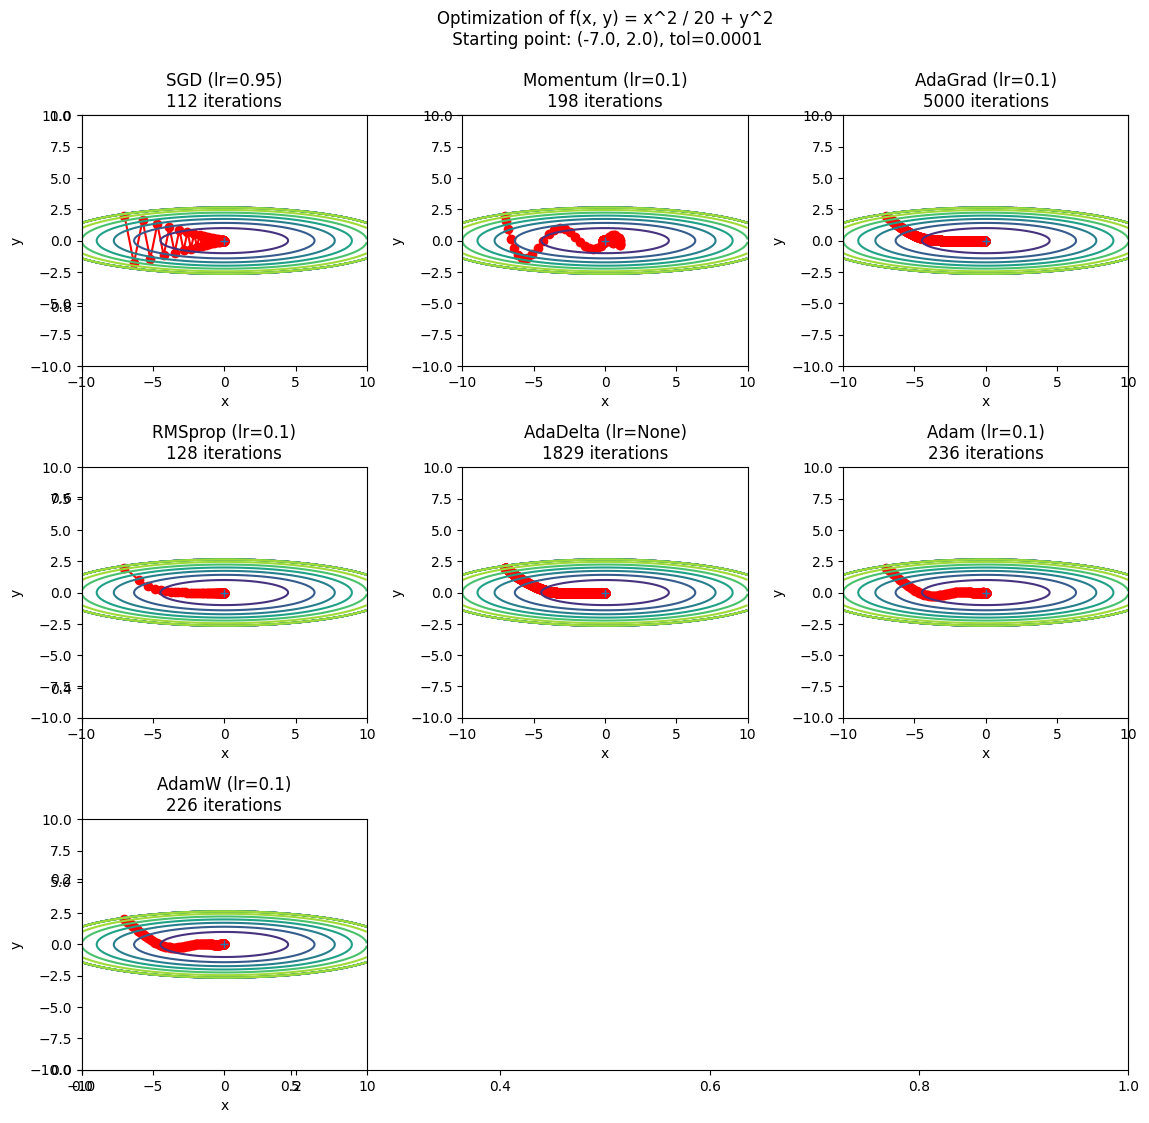

以下，重みパラメータを$\boldsymbol{W}$，損失関数を$L$，$\boldsymbol{W}$に関する損失関数の勾配$\frac{\partial L}{\partial \boldsymbol{W}}$，学習率を$\eta$とする．
### SGD(Stochastic Gradient Descent)
$$
    \boldsymbol{W} \leftarrow \boldsymbol{W} - \eta \cfrac{\partial L}{\partial \boldsymbol{W}}
$$



SGDでは，全データではなく，一部のデータから計算した勾配の平均で更新する．6章では，mini-batch SGDが用いられており，60000枚全てに対する平均勾配を毎回計算するのではなく，`batch_size`枚のミニバッチに対する平均勾配を計算し，その勾配に基づいて重みを更新する．

---

### Momentum
「速度」に対応する変数$\boldsymbol{v}$と，「過去の速度の保持率」を表す係数 $\alpha$ を導入する．一般に，$\alpha=0.9$が用いられている[1]．
$$
    \boldsymbol{v} \leftarrow \alpha\boldsymbol{v} - \eta \cfrac{\partial L}{\partial \boldsymbol{W}}
$$
$$
    \boldsymbol{W} \leftarrow \boldsymbol{W}+\boldsymbol{v}
$$
Momentumでは，過去の勾配(方向)を考慮して，パラメータを更新する．$\boldsymbol{v}$の更新は，$\boldsymbol{g}=\frac{\partial L}{\partial \boldsymbol{W}}$とすると，下記のように表される．
$$
    \boldsymbol{v_t} = \alpha \boldsymbol{v_{t-1}} - \eta \boldsymbol{g_t}  = -\eta \boldsymbol{g_t} - \alpha \eta \boldsymbol{g_{t-1}} - \alpha^2 \eta \boldsymbol{g_{t-2}} - \alpha^3 \eta \boldsymbol{g_{t-3}} - \cdots
$$
従って，Momentumは過去の勾配を指数的に減衰させながら足し合わせる方法と解釈できる．$\alpha$が大きいほど過去の更新方向を強く保持するため，勾配(方向)が一貫している方向には加速し，勾配の符号が振動する方向では更新が打ち消し合いやすくなる．その結果，損失関数の谷をジグザグに進むような oscillation を抑制できる．

[1] S. Ruder, “An overview of gradient descent optimization algorithms”, arXiv preprint arXiv:1609.04747, pp. 1–14, Jun. 2016]

---

### Adagrad
Momentumでは基準となる学習率 $\eta$ は全パラメータで共通であるが，AdaGradでは過去の勾配を基に，各パラメータごとに実質的な学習率を調整する．過去の勾配を二乗和として保持する項として，$\boldsymbol{h}$を導入する．
$$
    \boldsymbol{h} \leftarrow \boldsymbol{h} + \cfrac{\partial L}{\partial \boldsymbol{W}} \odot \cfrac{\partial L}{\partial \boldsymbol{W}}
$$
$\frac{1}{\sqrt{\boldsymbol{h}}}$によって，パラメータの各要素に適合した学習率に調整する. \epsion はゼロ除算を防ぐ小さな正数である．
$$
    \boldsymbol{W} \leftarrow \boldsymbol{W} - \eta \cfrac{1}{\sqrt{\boldsymbol{h}+\epsilon}} \odot \cfrac{\partial L}{\partial \boldsymbol{W}}
$$

Adagradでは，過去に大きな勾配を受けたパラメータほど$\boldsymbol{h}$が大きくなる為，そのパラメータの実質学習率は小さくなる．一方で，あまり更新されていないパラメータでは，$\boldsymbol{h}$が小さいため，相対的に大きな更新が行われる．

例えば，$\boldsymbol{W}\in \mathbb{R}^{J\times K}$の場合は，
$$
    h_{jk} \leftarrow h_{jk} + \left( \cfrac{\partial L}{\partial w_{jk}} \right)^2   \\
    w_{jk} \leftarrow w_{jk} - \eta \frac{1}{\sqrt{h_{jk}}+\epsilon} \cfrac{\partial L}{\partial w_{jk}}
$$

$\boldsymbol{h}$ は更新のたびに単調増加するため，学習が進むにつれて有効学習率が小さくなりすぎる場合がある．この問題を緩和する方向で RMSProp や AdaDelta が提案された．

※今回の実装では，$\boldsymbol{h}_0 = \boldsymbol{0}$として初期化している．

---

以下では，時刻 $t$ の勾配を

$$
\boldsymbol{g}_t
=
\cfrac{\partial L}{\partial \boldsymbol{W}_t}
$$

と書く．また，$\odot$ は要素ごとの積，$\sqrt{\cdot}$ や割り算も要素ごとの演算とする．

---

### RMSProp

AdaGradと異なり，過去の勾配2乗を **全履歴の和** ではなく，勾配2乗の**指数移動平均** として保持する．

まず，時刻 $t$ における勾配を

$$
\boldsymbol{g}_t
=

\frac{\partial L}{\partial \boldsymbol{W}_t}
$$

とする．

勾配二乗の指数移動平均を保持する変数として，$\boldsymbol{h}_t$ を導入する．

$$
\boldsymbol{h}_t
=

\rho \boldsymbol{h}_{t-1}
+
(1-\rho)
\boldsymbol{g}_t \odot \boldsymbol{g}_t
$$

ここで，$\rho$ は過去の情報をどれくらい残すかを決める係数（典型的には，$\rho = 0.9$）であり，$\odot$ は要素ごとの積を表す．

RMSProp では，この $\boldsymbol{h}_t$ を用いて各パラメータごとの実質的な学習率を調整し，

$$
\boldsymbol{W}_{t+1}
=

\boldsymbol{W}_t
\odot
\eta
\frac{1}{\sqrt{\boldsymbol{h}_t}+\epsilon}
\odot
\boldsymbol{g}_t
$$

と更新する．$\boldsymbol{h}_t\in \mathbb{R}^{J\times W}$とすれば，RMSProp では，最近大きな勾配を受けたパラメータでは $h^{j, k}_t$ が大きくなるため，実質的な学習率

$$
\frac{\eta}{\sqrt{h^{j, k}_t}+\epsilon}
$$

は小さくなる．一方で，最近あまり大きな勾配を受けていないパラメータでは $h^{j,k}_t$ が小さくなり，相対的に大きな更新が行われる．

AdaGrad との違いは，$\boldsymbol{h}_t$ が全履歴の和ではなく指数移動平均である点である．そのため，AdaGrad のように $\boldsymbol{h}_t$ が単調増加し続けることはなく，有効学習率が小さくなり続ける問題を緩和できる．

RMSProp は，AdaGrad の「各パラメータごとに学習率を調整する」という利点を残しつつ，学習率が小さくなり続ける問題を緩和した手法と言える．

---

### AdaDelta

RMSPropと似ているが，AdaDelta は 勾配2乗の指数移動平均 に加えて， 更新量2乗の指数移動平均 も用いる．

<!-- 勾配二乗の指数移動平均 $E[\boldsymbol{g}^2]_t$ と，更新量二乗の指数移動平均 $E[\Delta \boldsymbol{W}^2]_t$ を表す，$\boldsymbol{h}, \boldsymbol{s}$を導入する．

$$
    \boldsymbol{h}_t = E[\boldsymbol{g}^2]_t \\
    \boldsymbol{s}_t = E[\Delta \boldsymbol{W}^2]_t \\
$$ -->

- 勾配の二乗平均を保持する項 : $\boldsymbol{h}$ （＝勾配2乗の指数移動平均）
- 更新量の二乗平均を保持する項として，$\boldsymbol{s}$（＝更新量2乗の指数移動平均）

を導入する．ある時刻$t$における，$\boldsymbol{h}_t, \boldsymbol{s}_t$の更新式は次式で表される．ここで，$\rho$ は過去の情報をどれくらい残すかを決める係数（ハイパーパラメータ）で，$\Delta \boldsymbol{W}_t = \boldsymbol{W}_{t+1} - \boldsymbol{W}_t$である（典型的には，$\rho = 0.9$）．

$$
\boldsymbol{h}_t
=
\rho \boldsymbol{h}_{t-1}
+
(1-\rho)
\boldsymbol{g}_t \odot \boldsymbol{g}_t
$$

$$
\boldsymbol{s}_t
=
\rho \boldsymbol{s}_{t-1}
+
(1-\rho)
\Delta \boldsymbol{W}_t \odot \Delta \boldsymbol{W}_t
$$


次に，勾配 $\boldsymbol{g}_t$，更新量 $\Delta \boldsymbol{W}_t$ の RMS (Root Mean Square; 二乗平均平方根) を

$$
\text{RMS}[\boldsymbol{g}]_t
=
\sqrt{\boldsymbol{h}_t+\epsilon}
, \quad 
\text{RMS}[\Delta \boldsymbol{W}]_{t-1}
=
\sqrt{\boldsymbol{s}_{t-1}+\epsilon}
$$

と定義する．AdaDelta では，Adagrad における有効学習率
$$
\frac{\eta}{\sqrt{\boldsymbol{h}}+ \epsilon}
$$
の代わりに，更新量 $\Delta \boldsymbol{W}_t$ を次のように定める．

$$
\Delta \boldsymbol{W}_t
=
-
\frac{\text{RMS}[\Delta \boldsymbol{W}]_{t-1}}{\text{RMS}[\boldsymbol{g}]_t}
=
-
\frac{\sqrt{\boldsymbol{s}_{t-1}+\epsilon}}
{\sqrt{\boldsymbol{h}_t+\epsilon}}
\odot
\boldsymbol{g}_t
$$

となる．
実際に重みを更新すると，

$$
\boldsymbol{W}_{t+1}
=
\boldsymbol{W}_t
+
\Delta \boldsymbol{W}_t
$$

最後に，今回の更新量の二乗を，次回以降のために蓄積する．

$$
\boldsymbol{s}_t
=
\rho \boldsymbol{s}_{t-1}
+
(1-\rho)
\Delta \boldsymbol{W}_t
\odot
\Delta \boldsymbol{W}_t
$$

尚，更新手順は次の通り；

1. $\boldsymbol{h}_t$ を更新する
$$
\boldsymbol{g}_t
=
\cfrac{\partial L}{\partial \boldsymbol{W}}
$$

2. $\boldsymbol{s}_{t-1}$ と $\boldsymbol{h}_t$ から $\Delta \boldsymbol{W}_t$ を計算する
$$
\boldsymbol{h}_t
=
\rho \boldsymbol{h}_{t-1}
+
(1-\rho)
\boldsymbol{g}_t \odot \boldsymbol{g}_t
$$

$$
\Delta \boldsymbol{W}_t
=
-
\frac{\sqrt{\boldsymbol{s}_{t-1}+\epsilon}}
{\sqrt{\boldsymbol{h}_t+\epsilon}}
\boldsymbol{g}_t
$$

3. $\boldsymbol{W}_{t+1}$ を更新する
$$
\boldsymbol{W}_{t+1}
=
\boldsymbol{W}_t
+
\Delta \boldsymbol{W}_t
$$

4. 最後に $\boldsymbol{s}_t$ を更新する
$$
\boldsymbol{s}_t
=
\rho \boldsymbol{s}_{t-1}
+
(1-\rho)
\Delta \boldsymbol{W}_t \odot \Delta \boldsymbol{W}_t
$$

※今回の実装では，$\boldsymbol{h}_0 = \boldsymbol{s}_0 = \boldsymbol{0}$として初期化している．


<!-- > AdaDelta は，元論文の標準形では明示的な学習率 $\eta$ を使わない形で書かれることが多い．ただし実装によっては，
> $$
> \Delta \boldsymbol{W}_t
> \leftarrow
> -
> \eta
> \frac{\sqrt{\boldsymbol{s}+\epsilon}}
> {\sqrt{\boldsymbol{h}+\epsilon}}
> \boldsymbol{g}_t
> $$
> のように，外側に学習率 $\eta$ を掛ける場合もある． -->

---

### Adam

Adam は，Momentum と Adagrad / RMSProp を合わせたような方法である．
つまり，

* 勾配そのものの指数移動平均：$\boldsymbol{m}$
* 勾配二乗の指数移動平均：$\boldsymbol{v}$

を保持する．$\boldsymbol{m}$ を 1次モーメント(first moment)，$\boldsymbol{v}$ を 2次モーメント(second raw moment) と呼ぶ．
ただし，$\boldsymbol{m}_0=\boldsymbol{0}$，$\boldsymbol{v}_0=\boldsymbol{0}$ と初期化するため，学習の初期では $\boldsymbol{m}_t$ と $\boldsymbol{v}_t$ が小さめに見積もられる．そこで，バイアス補正を行った $\hat{\boldsymbol{m}}_t$ と $\hat{\boldsymbol{v}}_t$ を用いる．

まず，時刻$t$における勾配を

$$
\boldsymbol{g}_t
=
\cfrac{\partial L}{\partial \boldsymbol{W}}
$$

と計算する．

次に，勾配の指数移動平均を更新する．これは Momentum の速度に近い役割を持つ．

$$
\boldsymbol{m}_{t}
=
\beta_1 \boldsymbol{m}_{t-1}
+
(1-\beta_1)\boldsymbol{g}_t
$$

次に，勾配二乗の指数移動平均を更新する．
これは Adagrad の $\boldsymbol{h}$ に近い役割を持つが，全履歴の和ではなく指数移動平均である．

$$
\boldsymbol{v}_t
=
\beta_2 \boldsymbol{v}_{t-1}
+
(1-\beta_2)
\boldsymbol{g}_t \odot \boldsymbol{g}_t
$$

ただし，$\boldsymbol{m}$ と $\boldsymbol{v}$ は初期値を $0$ にするため，学習の初期では小さめに見積もられる．
そこで，バイアス補正を行う．

$$
\hat{\boldsymbol{m}_t}
=
\frac{\boldsymbol{m_t}}{1-\beta_1^t}
$$

$$
\hat{\boldsymbol{v}_t}
=
\frac{\boldsymbol{v}_t}{1-\beta_2^t}
$$

最後に，重みを更新する．

$$
\boldsymbol{W}_{t+1}
=
\boldsymbol{W}_{t}
-
\eta
\frac{\hat{\boldsymbol{m}_t}}
{\sqrt{\hat{\boldsymbol{v}_t}}+\epsilon}
$$

<!-- まとめると，

$$
\boldsymbol{g}_t
=
\cfrac{\partial L}{\partial \boldsymbol{W}}
$$

$$
\boldsymbol{m}_t
=
\beta_1 \boldsymbol{m}_{t-1}
+
(1-\beta_1)\boldsymbol{g}_t
$$

$$
\boldsymbol{v}_t
\leftarrow
\beta_2 \boldsymbol{v}_{t-1}
+
(1-\beta_2)
\boldsymbol{g}_t \odot \boldsymbol{g}_t
$$

$$
\hat{\boldsymbol{m}_t}
=
\frac{\boldsymbol{m_t}}{1-\beta_1^t}
$$

$$
\hat{\boldsymbol{v}_t}
=
\frac{\boldsymbol{v}_t}{1-\beta_2^t}
$$

$$
\boldsymbol{W}_{t+1}
=
\boldsymbol{W}_{t}
-
\eta
\frac{\hat{\boldsymbol{m}_t}}
{\sqrt{\hat{\boldsymbol{v}_t}}+\epsilon}
$$ -->

> 典型的な値は，
> $$
> \beta_1 = 0.9,\quad
> \beta_2 = 0.999,\quad
> \epsilon = 10^{-8}
> $$
> である．

---


## AdamW

AdamW は，Adam に **Weight Decay** を正しく組み込んだ方法である．
重要なのは，AdamW では Weight Decay を勾配に混ぜないことである．

通常の Adam に L2 正則化を入れると，
$$
L_{\text{reg}}(\boldsymbol{W}_{t}) = L(\boldsymbol{W}_t) + \cfrac{\lambda}{2} ||\boldsymbol{W}_t||^2_2
$$
勾配を計算すると，
$$
\boldsymbol{g}_t^{\text{reg}}
=
\cfrac{\partial L}{\partial \boldsymbol{W}_t}
+
\lambda \boldsymbol{W}_t
=
\boldsymbol{g}_t + \lambda\boldsymbol{W}_t
$$
<!-- - Adamの1次モーメントは，
    $$
        \boldsymbol{m}_t =  \beta_1 \boldsymbol{m}_{t-1} + (1-\beta_1) (\boldsymbol{g}_t+\lambda \boldsymbol{W}_t) 
        = \beta_1 \boldsymbol{m}_{t-1} + (1-\beta_1) \boldsymbol{g}_t+ (1-\beta_1)\lambda \boldsymbol{W}_t
    $$
- Adam の2次モーメントは，
    $$
        \boldsymbol{v}_t = \beta_2 \boldsymbol{v}_{t-1} + (1-\beta_2)(\boldsymbol{g}_t + \lambda \boldsymbol{W}_t) \odot (\boldsymbol{g}_t + \lambda \boldsymbol{W}_t)
        = \boldsymbol{v}_t = \beta_2 \boldsymbol{v}_{t-1} + (1-\beta_2)(\boldsymbol{g}_t \odot \boldsymbol{g}_t + 2\lambda \boldsymbol{g}_t \odot \boldsymbol{W}_t + \lambda^2 \boldsymbol{W}_t \odot \boldsymbol{W}_t)
    $$ -->

しかし Adam の場合，この $\lambda \boldsymbol{W}_t$ も

$$
\frac{1}{\sqrt{\hat{\boldsymbol{v}_t}}+\epsilon}
$$

によってスケーリングされてしまう．SGD とは異なり，Adam では L2正則化 と Weight Decay は等価ではない．
AdamW では，まず Adam と同じように勾配を計算するが，**Weight Decay 項を勾配に足さず，勾配更新から分離する**．

$$
\boldsymbol{g}_t
=
\cfrac{\partial L}{\partial \boldsymbol{W}}
$$

Adam と同様に，1次モーメントを更新する．

$$
\boldsymbol{m}_t
=
\beta_1 \boldsymbol{m}_{t-1}
+
(1-\beta_1)\boldsymbol{g}_t
$$

2次モーメントも更新する．

$$
\boldsymbol{v}_t
=
\beta_2 \boldsymbol{v}_{t-1}
+
(1-\beta_2)
\boldsymbol{g}_t \odot \boldsymbol{g}_t
$$

バイアス補正を行う．

$$
\hat{\boldsymbol{m}_t}
=
\frac{\boldsymbol{m}_t}{1-\beta_1^t}
$$

$$
\hat{\boldsymbol{v}_t}
=
\frac{\boldsymbol{v}_t}{1-\beta_2^t}
$$

そして，Weight Decay を用いて，直接重みを減衰させる．

$$
\boldsymbol{W}
=
\boldsymbol{W}
-
\eta
\frac{\hat{\boldsymbol{m}}}
{\sqrt{\hat{\boldsymbol{v}}}+\epsilon}
-
\eta \lambda \boldsymbol{W}
=
(1-\eta\lambda)\boldsymbol{W}
-
\eta
\frac{\hat{\boldsymbol{m}}}
{\sqrt{\hat{\boldsymbol{v}}}+\epsilon}
$$

である．

<!-- これによって，Adamの収束性能とSGDの汎化性能を両立した． -->

<!-- 
まとめると，

$$
\boldsymbol{g}_t
=
\cfrac{\partial L}{\partial \boldsymbol{W}}
$$

$$
\boldsymbol{m}
\leftarrow
\beta_1 \boldsymbol{m}
+
(1-\beta_1)\boldsymbol{g}_t
$$

$$
\boldsymbol{v}
\leftarrow
\beta_2 \boldsymbol{v}
+
(1-\beta_2)
\boldsymbol{g}_t \odot \boldsymbol{g}_t
$$

$$
\hat{\boldsymbol{m}}
\leftarrow
\frac{\boldsymbol{m}}{1-\beta_1^t}
$$

$$
\hat{\boldsymbol{v}}
\leftarrow
\frac{\boldsymbol{v}}{1-\beta_2^t}
$$

$$
\boldsymbol{W}
\leftarrow
\boldsymbol{W}
-
\eta
\frac{\hat{\boldsymbol{m}}}
{\sqrt{\hat{\boldsymbol{v}}}+\epsilon}
-
\eta \lambda \boldsymbol{W}
$$

または，

$$
\boldsymbol{W}
\leftarrow
(1-\eta\lambda)\boldsymbol{W}
-
\eta
\frac{\hat{\boldsymbol{m}}}
{\sqrt{\hat{\boldsymbol{v}}}+\epsilon}
$$ -->

<!-- ---

## 要素ごとに書くと

例えば，$\boldsymbol{W}\in \mathbb{R}^{J\times K}$ の場合，Adam では各要素 $w_{jk}$ について，

$$
g_{jk,t}
=
\cfrac{\partial L}{\partial w_{jk}}
$$

$$
m_{jk}
\leftarrow
\beta_1 m_{jk}
+
(1-\beta_1)g_{jk,t}
$$

$$
v_{jk}
\leftarrow
\beta_2 v_{jk}
+
(1-\beta_2)g_{jk,t}^2
$$

$$
\hat{m}*{jk}
\leftarrow
\frac{m*{jk}}{1-\beta_1^t}
$$

$$
\hat{v}*{jk}
\leftarrow
\frac{v*{jk}}{1-\beta_2^t}
$$

$$
w_{jk}
\leftarrow
w_{jk}
-
\eta
\frac{\hat{m}*{jk}}
{\sqrt{\hat{v}*{jk}}+\epsilon}
$$

AdamW では最後だけ，

$$
w_{jk}
\leftarrow
w_{jk}
-
\eta
\frac{\hat{m}*{jk}}
{\sqrt{\hat{v}*{jk}}+\epsilon}
-
\eta\lambda w_{jk}
$$

となる． -->
---

Adagrad
 iter |            x            y |      dist |        h_x        h_y |   eff_lr_x   eff_lr_y |     step_x     step_y
------------------------------------------------------------------------------------------------------------------------
    0 |    -7.000000    +2.000000 |  7.28e+00 |     0.0000     0.0000 |   1.00e+06   1.00e+06 |   7.00e+05   4.00e+06
    1 |    -6.900000    +1.900000 |  7.16e+00 |     0.4900    16.0000 |   1.43e-01   2.50e-02 |   9.86e-02   9.50e-02
    5 |    -6.679568    +1.686762 |  6.89e+00 |     2.3433    68.4179 |   6.53e-02   1.21e-02 |   4.36e-02   4.08e-02
   10 |    -6.504978    +1.523979 |  6.68e+00 |     4.5248   120.7517 |   4.70e-02   9.10e-03 |   3.06e-02   2.77e-02
   50 |    -5.770968    +0.907994 |  5.84e+00 |    19.4200   345.7512 |   2.27e-02   5.38e-03 |   1.31e-02   9.77e-03
  100 |    -5.239474    +0.551346 |  5.27e+00 |    34.5224   450.0226 |   1.70e-02   4.71e-03 |   8.92e-03   5.20e-03
  500 |    -3.241881    +0.015573 |  3.24e+00

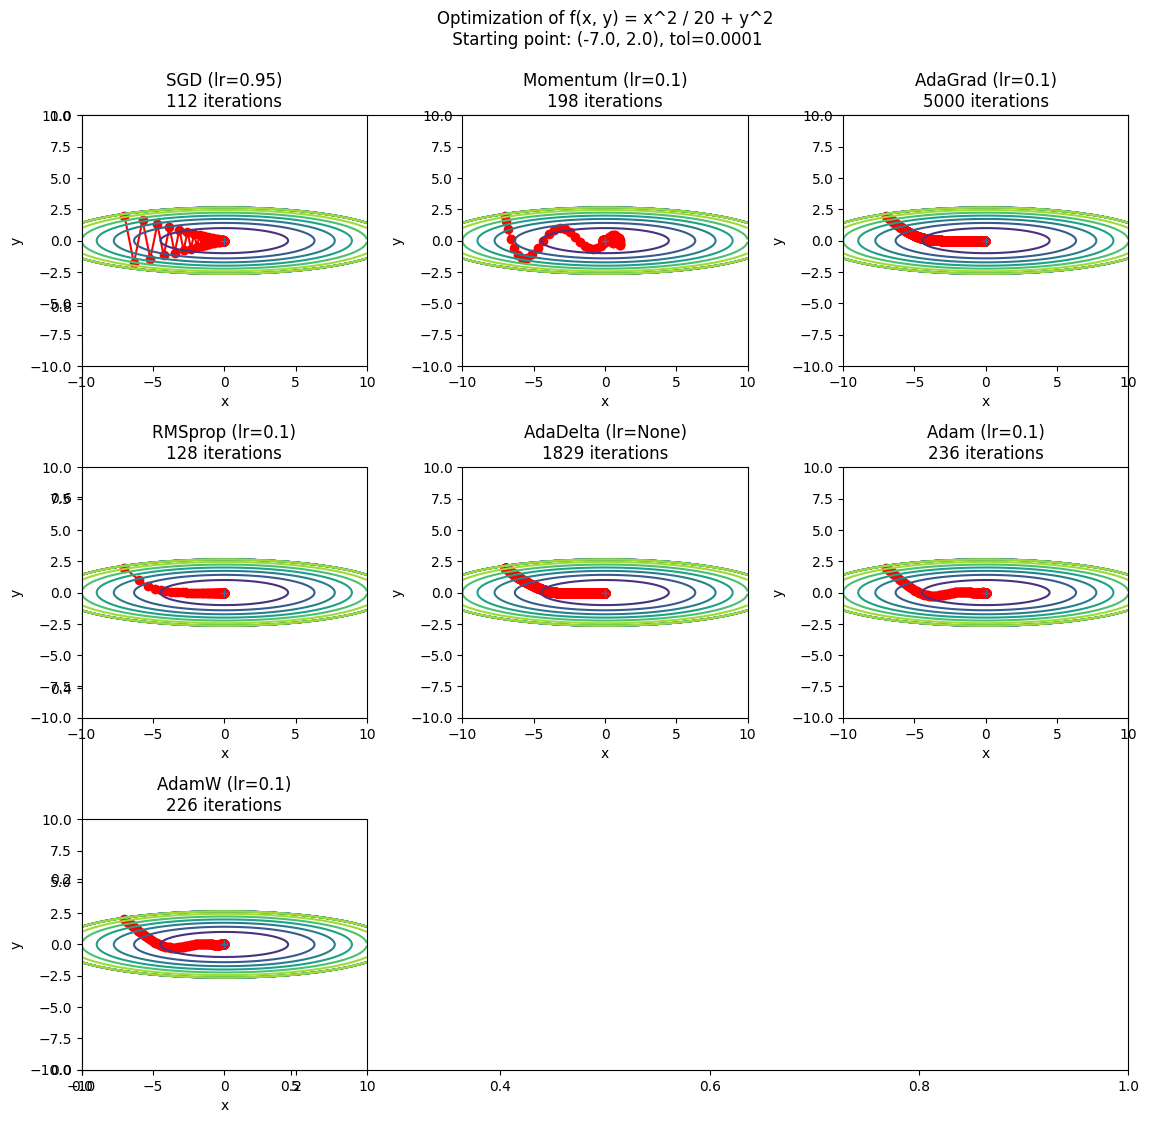

In [58]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0

max_iterations = 5000
tol = 1e-4
lrs = [
    0.95,
    0.1,
    0.1,
    0.1,  # RMSprop
    None,
    0.1,
    0.1,
]

optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=lrs[0])  
optimizers["Momentum"] = Momentum(lr=lrs[1])  
optimizers["AdaGrad"] = AdaGrad(lr=lrs[2])
optimizers["RMSprop"] = RMSprop(lr=lrs[3])
optimizers["AdaDelta"] = AdaDelta()
optimizers["Adam"] = Adam(lr=lrs[5])
optimizers["AdamW"] = AdamW(lr=lrs[6])

plt.figure(figsize=(12, 12))
plt.title(f"Optimization of f(x, y) = x^2 / 20 + y^2\n Starting point: {init_pos}, tol={tol}\n\n\n")
idx = 1

# AdaGrad の実効学習率を表示するチェックポイント
adagrad_checkpoints = {0, 1, 5, 10, 50, 100, 500, 1000, 2000, 3000, 4000, 4999}

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]

    if key == "AdaGrad":
        print("Adagrad")
        print(f"{'iter':>5} | {'x':>12} {'y':>12} | {'dist':>9} | {'h_x':>10} {'h_y':>10} | {'eff_lr_x':>10} {'eff_lr_y':>10} | {'step_x':>10} {'step_y':>10}")
        print("-" * 120)

    n_iter = max_iterations
    for i in range(max_iterations):
        x_history.append(params['x'])
        y_history.append(params['y'])

        grads['x'], grads['y'] = df(params['x'], params['y'])

        # AdaGrad の実効学習率を表示
        if key == "AdaGrad" and i in adagrad_checkpoints:
            h_x = optimizer.h['x'] if optimizer.h else 0.0
            h_y = optimizer.h['y'] if optimizer.h else 0.0
            eff_lr_x = optimizer.lr / (np.sqrt(h_x) + 1e-7)
            eff_lr_y = optimizer.lr / (np.sqrt(h_y) + 1e-7)
            dist = np.sqrt(params['x']**2 + params['y']**2)
            step_x = eff_lr_x * abs(grads['x'])
            step_y = eff_lr_y * abs(grads['y'])
            print(f"{i:5d} | {params['x']:+12.6f} {params['y']:+12.6f} | {dist:9.2e} | {h_x:10.4f} {h_y:10.4f} | {eff_lr_x:10.2e} {eff_lr_y:10.2e} | {step_x:10.2e} {step_y:10.2e}")

        optimizer.update(params, grads)

        if np.sqrt(params['x']**2 + params['y']**2) < tol:
            n_iter = i + 1
            break

    if key == "AdaGrad":
        dist = np.sqrt(params['x']**2 + params['y']**2)
        eff_lr_x = optimizer.lr / (np.sqrt(optimizer.h['x']) + 1e-7)
        eff_lr_y = optimizer.lr / (np.sqrt(optimizer.h['y']) + 1e-7)
        print("-" * 120)
        print(f"Final | {params['x']:+12.6f} {params['y']:+12.6f} | {dist:9.2e} | eff_lr_x={eff_lr_x:.2e} (base lr の {eff_lr_x/optimizer.lr:.1%}), tol={tol}")
        print()

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)

    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    # for simple contour line
    mask = Z > 7
    Z[mask] = 0

    # plot
    plt.subplot(3, 3, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    plt.title(key + f" (lr={lrs[idx-2]})\n{n_iter} iterations")
    plt.xlabel("x")
    plt.ylabel("y")

plt.tight_layout()
plt.savefig("optimization_comparison.png")
plt.show()